In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Read in saved test set with predicted and actual label

In [2]:
test_results_df = pd.read_csv('test_predictions.csv')

# Promotional Campaign Effectiveness Simulation

In [4]:
# Define Business Rules

#COSTS (False Positives - Predicted Churn but Actually No Churn):
#TotalCharges > 2400: 80% accept campaign → cost = 3 × MonthlyCharges
#TotalCharges ≤ 2400: 80% accept campaign → cost = 1 × MonthlyCharges

#REVENUE (True Positives - Predicted Churn and Actually Churn):
#TotalCharges > 2400: 35% accept campaign → revenue = 9 × MonthlyCharges
#TotalCharges ≤ 2400: 35% accept campaign → revenue = 11 × MonthlyCharges

In [12]:
def simulate_campaign_impact(df, random_seed=42):
    np.random.seed(random_seed)
    
    # Create copy to avoid modifying original
    sim_df = df.copy()
    
    # COSTS: False Positives (Predicted=1, Actual=0)
    false_positives = sim_df[(sim_df['Predicted_Churn'] == 1) & (sim_df['Actual_Churn'] == 0)].copy()
    
    if len(false_positives) > 0:
        # Determine campaign acceptance (80% chance)
        false_positives['Accepted_Campaign'] = np.random.random(len(false_positives)) < 0.80
        
        # Calculate cost based on TotalCharges
        false_positives['Cost_Months'] = np.where(
            false_positives['TotalCharges'] > 2400,
            3,  # 3 months free
            1   # 1 month free
        )
        
        # Calculate total cost per customer (only if they accepted)
        false_positives['Cost'] = np.where(
            false_positives['Accepted_Campaign'],
            false_positives['Cost_Months'] * false_positives['MonthlyCharges'],
            0
        )
        
        total_cost = false_positives['Cost'].sum()
        n_costs = false_positives['Accepted_Campaign'].sum()
    else:
        total_cost = 0
        n_costs = 0
    
    # REVENUE: True Positives (Predicted=1, Actual=1)
    true_positives = sim_df[(sim_df['Predicted_Churn'] == 1) & (sim_df['Actual_Churn'] == 1)].copy()
    
    if len(true_positives) > 0:
        # Determine campaign acceptance (35% chance)
        true_positives['Accepted_Campaign'] = np.random.random(len(true_positives)) < 0.35
        
        # Calculate revenue months based on TotalCharges
        true_positives['Revenue_Months'] = np.where(
            true_positives['TotalCharges'] > 2400,
            9,   # 9 months revenue
            11   # 11 months revenue
        )
        
        # Calculate total revenue per customer (only if they accepted)
        true_positives['Revenue'] = np.where(
            true_positives['Accepted_Campaign'],
            true_positives['Revenue_Months'] * true_positives['MonthlyCharges'],
            0
        )
        
        total_revenue = true_positives['Revenue'].sum()
        n_revenues = true_positives['Accepted_Campaign'].sum()
    else:
        total_revenue = 0
        n_revenues = 0
    
    # Calculate Net Impact
    net_impact = total_revenue - total_cost
    
    # Calculate average per customer
    avg_cost_per_accepted = total_cost / n_costs if n_costs > 0 else 0
    avg_revenue_per_accepted = total_revenue / n_revenues if n_revenues > 0 else 0
    
    return {
        'total_cost': total_cost,
        'total_revenue': total_revenue,
        'net_impact': net_impact,
        'n_costs': n_costs,
        'n_revenues': n_revenues,
        'avg_cost_per_accepted': avg_cost_per_accepted,
        'avg_revenue_per_accepted': avg_revenue_per_accepted,
    }

## Monte Carlo Simiulation

In [13]:
n_simulations = 500
print(f"Number of Simulations: {n_simulations}")

# Store all results
all_results = []

for i in range(n_simulations):
    result = simulate_campaign_impact(test_results_df, random_seed=i*42)
    all_results.append({
        'simulation': i,
        'total_cost': result['total_cost'],
        'total_revenue': result['total_revenue'],
        'net_impact': result['net_impact'],
        'n_costs': result['n_costs'],
        'n_revenues': result['n_revenues'],
        'avg_cost_per_accepted': result['avg_cost_per_accepted'],
        'avg_revenue_per_accepted': result['avg_revenue_per_accepted']
    })

# Convert to DataFrame
results_df = pd.DataFrame(all_results)

Number of Simulations: 500


In [14]:
results_df

,simulation,total_cost,total_revenue,net_impact,n_costs,n_revenues,avg_cost_per_accepted,avg_revenue_per_accepted
0,0,29776.20,91891.35,62115.15,234,109,127.248718,843.039908
1,1,28310.20,71385.70,43075.50,227,90,124.714537,793.174444
2,2,30924.50,71692.50,40768.00,238,89,129.934874,805.533708
3,3,29804.50,76712.60,46908.10,238,96,125.228992,799.089583
4,4,28051.70,71302.05,43250.35,230,89,121.963913,801.146629
...,...,...,...,...,...,...,...,...
495,495,29834.45,81897.50,52063.05,234,101,127.497650,810.866337
496,496,28681.35,87208.55,58527.20,221,106,129.779864,822.722170
497,497,29323.70,75108.60,45784.90,230,94,127.494348,799.027660
498,498,30213.10,84431.55,54218.45,241,105,125.365560,804.110000


## Baseline total net revenue if no intervention

In [18]:
(test_results_df['Actual_Churn'] * test_results_df['MonthlyCharges']).sum()*12

np.float64(326578.80000000005)

## Result Summary Table

In [19]:
# Summary statistics
summary = {
    'Metric': ['Total Cost', 'Total Revenue', 'Net Impact', 
               'Costs Accepted', 'Revenue Accepted',
               'Avg Cost per Accepted', 'Avg Revenue per Accepted'],
    'Mean': [
        results_df['total_cost'].mean(),
        results_df['total_revenue'].mean(),
        results_df['net_impact'].mean(),
        results_df['n_costs'].mean(),
        results_df['n_revenues'].mean(),
        results_df['avg_cost_per_accepted'].mean(),
        results_df['avg_revenue_per_accepted'].mean()
    ],
    'Std Dev': [
        results_df['total_cost'].std(),
        results_df['total_revenue'].std(),
        results_df['net_impact'].std(),
        results_df['n_costs'].std(),
        results_df['n_revenues'].std(),
        results_df['avg_cost_per_accepted'].std(),
        results_df['avg_revenue_per_accepted'].std()
    ],
    '95% CI Lower': [
        np.percentile(results_df['total_cost'], 2.5),
        np.percentile(results_df['total_revenue'], 2.5),
        np.percentile(results_df['net_impact'], 2.5),
        np.percentile(results_df['n_costs'], 2.5),
        np.percentile(results_df['n_revenues'], 2.5),
        np.percentile(results_df['avg_cost_per_accepted'], 2.5),
        np.percentile(results_df['avg_revenue_per_accepted'], 2.5)
    ],
    '95% CI Upper': [
        np.percentile(results_df['total_cost'], 97.5),
        np.percentile(results_df['total_revenue'], 97.5),
        np.percentile(results_df['net_impact'], 97.5),
        np.percentile(results_df['n_costs'], 97.5),
        np.percentile(results_df['n_revenues'], 97.5),
        np.percentile(results_df['avg_cost_per_accepted'], 97.5),
        np.percentile(results_df['avg_revenue_per_accepted'], 97.5)
    ]
}

summary_df = pd.DataFrame(summary)
summary_df['Mean'] = summary_df['Mean'].round(2)
summary_df['Std Dev'] = summary_df['Std Dev'].round(2)
summary_df['95% CI Lower'] = summary_df['95% CI Lower'].round(2)
summary_df['95% CI Upper'] = summary_df['95% CI Upper'].round(2)

print(summary_df.to_string(index=False))


                  Metric     Mean  Std Dev  95% CI Lower  95% CI Upper
              Total Cost 29475.94  1075.27      27206.26      31496.75
           Total Revenue 82574.65  6774.00      69900.63      95756.17
              Net Impact 53098.71  6827.42      40282.09      66542.94
          Costs Accepted   231.45     6.71        218.48        244.00
        Revenue Accepted   102.29     7.97         87.00        118.00
   Avg Cost per Accepted   127.35     2.86        121.74        132.81
Avg Revenue per Accepted   807.18    17.22        772.25        839.71


## Probability of Positive Net Impact

In [21]:
positive_prob = (results_df['net_impact'] > 0).mean() * 100

print(f"Probability of Positive Net Impact: {positive_prob:.1f}%")

print(f"\nExpected Net Impact: ${results_df['net_impact'].mean():,.2f}")
print(f"Best Case Net Impact: ${results_df['net_impact'].max():,.2f}")
print(f"Worst Case Net Impact: ${results_df['net_impact'].min():,.2f}")

Probability of Positive Net Impact: 100.0%

Expected Net Impact: $53,098.71
Best Case Net Impact: $72,982.00
Worst Case Net Impact: $33,805.05


## Result Visualization

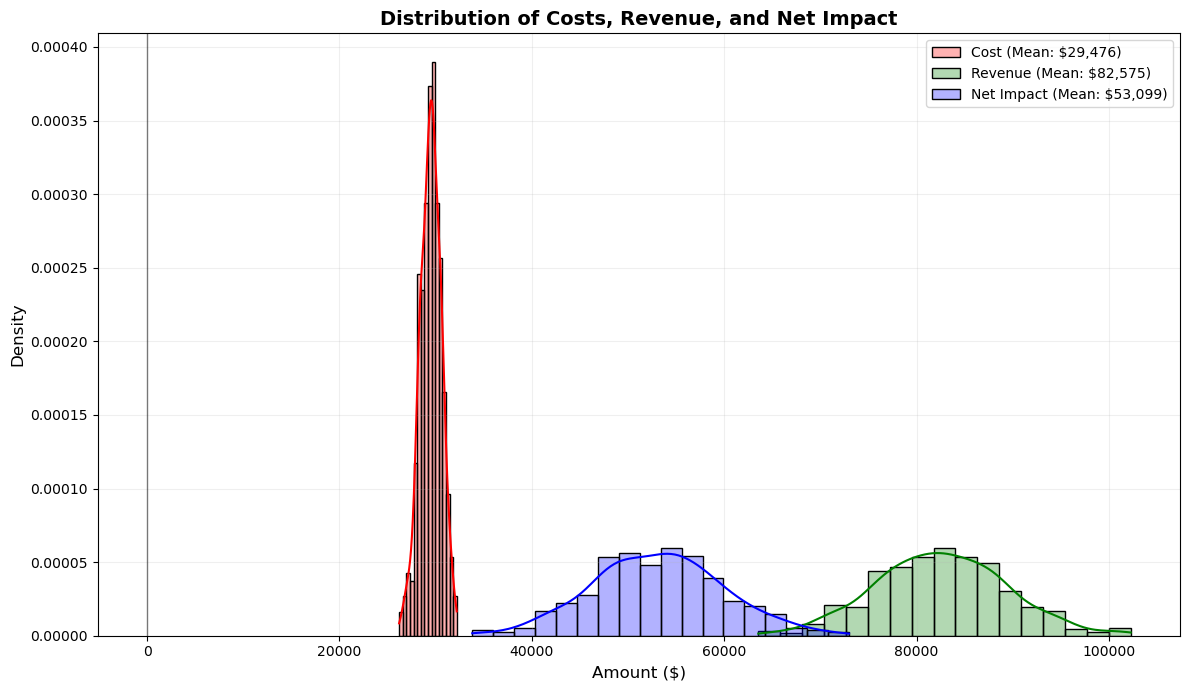

In [25]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot all three with histogram + KDE (smooth line)
sns.histplot(results_df['total_cost'], kde=True, color='red', 
             label=f'Cost (Mean: ${results_df["total_cost"].mean():,.0f})', 
             stat='density', alpha=0.3, ax=ax)

sns.histplot(results_df['total_revenue'], kde=True, color='green', 
             label=f'Revenue (Mean: ${results_df["total_revenue"].mean():,.0f})', 
             stat='density', alpha=0.3, ax=ax)

sns.histplot(results_df['net_impact'], kde=True, color='blue', 
             label=f'Net Impact (Mean: ${results_df["net_impact"].mean():,.0f})', 
             stat='density', alpha=0.3, ax=ax)

# Add break-even line
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Labels and title
ax.set_xlabel('Amount ($)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of Costs, Revenue, and Net Impact', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('campaign_simulation_distributions.png', dpi=450, bbox_inches='tight')
plt.show()

# Sensitivity Analysis

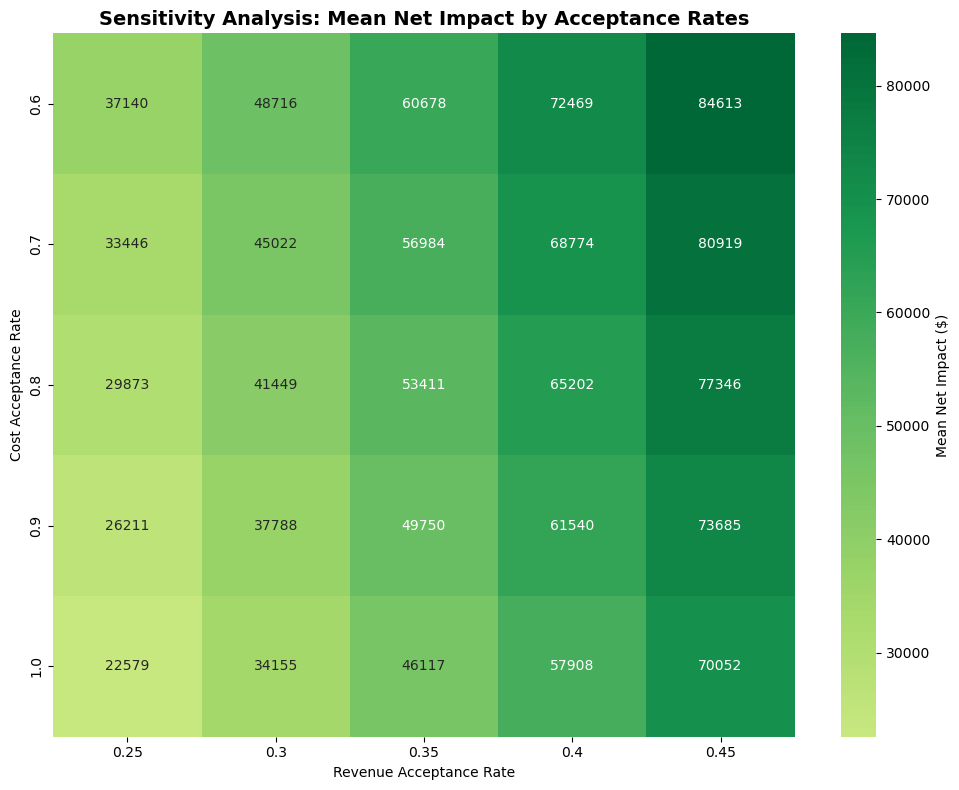

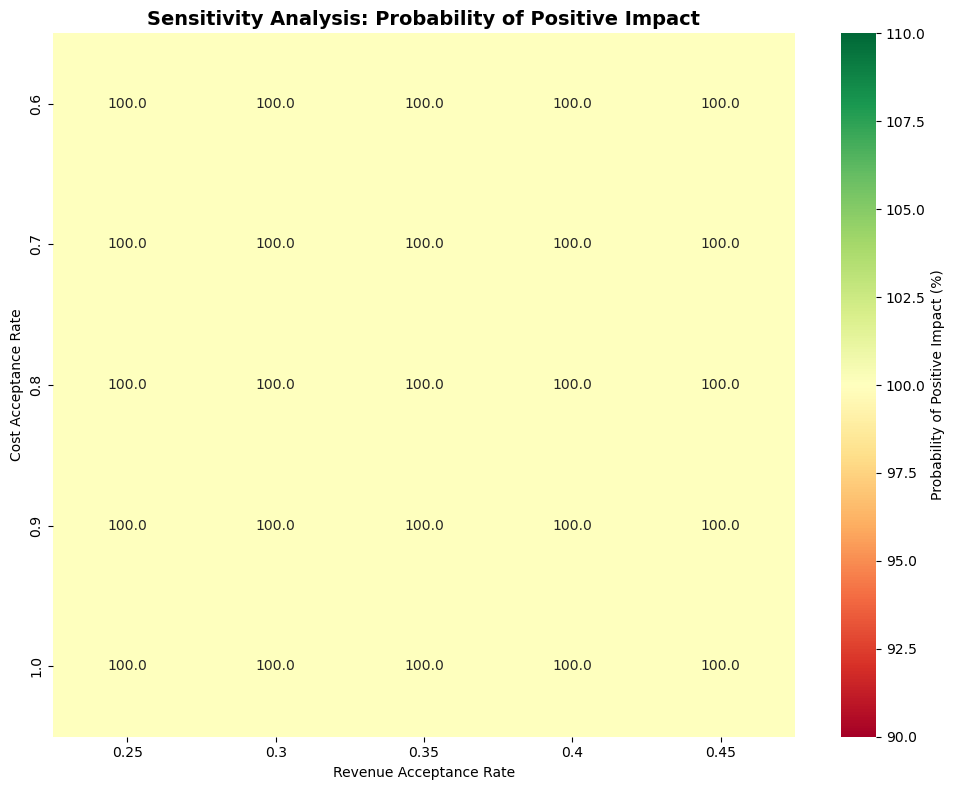

In [24]:
# Test different acceptance rates
cost_acceptance_rates = [0.60, 0.70, 0.80, 0.90, 1.00]
revenue_acceptance_rates = [0.25, 0.30, 0.35, 0.40, 0.45]

sensitivity_results = []

for cost_rate in cost_acceptance_rates:
    for rev_rate in revenue_acceptance_rates:
        temp_results = []
        for i in range(50):  # 50 simulations per combination
            # Custom simulation with specific rates
            np.random.seed(i*42)
            
            # False Positives
            fp = test_results_df[(test_results_df['Predicted_Churn'] == 1) & 
                                  (test_results_df['Actual_Churn'] == 0)].copy()
            if len(fp) > 0:
                fp['Accepted'] = np.random.random(len(fp)) < cost_rate
                fp['Cost'] = np.where(
                    fp['Accepted'],
                    np.where(fp['TotalCharges'] > 2400, 3, 1) * fp['MonthlyCharges'],
                    0
                )
                total_cost = fp['Cost'].sum()
            else:
                total_cost = 0
            
            # True Positives
            tp = test_results_df[(test_results_df['Predicted_Churn'] == 1) & 
                                  (test_results_df['Actual_Churn'] == 1)].copy()
            if len(tp) > 0:
                tp['Accepted'] = np.random.random(len(tp)) < rev_rate
                tp['Revenue'] = np.where(
                    tp['Accepted'],
                    np.where(tp['TotalCharges'] > 2400, 9, 11) * tp['MonthlyCharges'],
                    0
                )
                total_revenue = tp['Revenue'].sum()
            else:
                total_revenue = 0
            
            temp_results.append(total_revenue - total_cost)
        
        sensitivity_results.append({
            'Cost_Acceptance_Rate': cost_rate,
            'Revenue_Acceptance_Rate': rev_rate,
            'Mean_Net_Impact': np.mean(temp_results),
            'Median_Net_Impact': np.median(temp_results),
            'P5': np.percentile(temp_results, 5),
            'P95': np.percentile(temp_results, 95),
            'P_Positive': (np.array(temp_results) > 0).mean() * 100
        })

sensitivity_df = pd.DataFrame(sensitivity_results)

# Pivot for heatmap
pivot_mean = sensitivity_df.pivot(index='Cost_Acceptance_Rate', 
                                   columns='Revenue_Acceptance_Rate', 
                                   values='Mean_Net_Impact')
pivot_prob = sensitivity_df.pivot(index='Cost_Acceptance_Rate', 
                                   columns='Revenue_Acceptance_Rate', 
                                   values='P_Positive')

# Heatmap of Mean Net Impact
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_mean, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Mean Net Impact ($)'})
plt.title('Sensitivity Analysis: Mean Net Impact by Acceptance Rates', 
          fontsize=14, fontweight='bold')
plt.xlabel('Revenue Acceptance Rate')
plt.ylabel('Cost Acceptance Rate')
plt.tight_layout()
plt.savefig('sensitivity_heatmap_mean.png', dpi=450, bbox_inches='tight')
plt.show()

# Heatmap of Probability of Positive Impact
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_prob, annot=True, fmt='.1f', cmap='RdYlGn', 
            cbar_kws={'label': 'Probability of Positive Impact (%)'})
plt.title('Sensitivity Analysis: Probability of Positive Impact', 
          fontsize=14, fontweight='bold')
plt.xlabel('Revenue Acceptance Rate')
plt.ylabel('Cost Acceptance Rate')
plt.tight_layout()
plt.savefig('sensitivity_heatmap_prob.png', dpi=450, bbox_inches='tight')
plt.show()